In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from lacbox.io import load_stats, load_oper

In [46]:
# analysis settings
HAWC2S_PATH = r'C:\Users\hrara\Documents\46320_LAC\LAC_Assignments_Git\hawc_files\our_design\data\group7_3B_design_flex.opt'  # path to .pwr or .opt file
STATS_PATH = r'C:\Users\hrara\Documents\46320_LAC\LAC_Assignments_Git\A4 Design Loads and AEP\Assignment/group7_turbB_stats_ts.csv'  # path to mean steady stats
SUBFOLDER = 'tcb'  # which subfolder to plot: tca or tcb

# turbine constants
GENEFF = 0.94  # generator/gearbox efficienty [%]
FG_TIMES_DY = 6250  # yaw-bearing pitch moment due to gravity [kNm]
if 'notilt' in SUBFOLDER:
    DZ_YB = 2.75  # distance from hub center to yaw bearing [m]
    DZ_TB = 115.63 + DZ_YB  # distance from hub center to tower base [m]
else:
    DZ_YB = 2.75 + 7.1*np.sin(5*np.pi/180)  # distance from hub center to yaw bearing [m]
    DZ_TB = 115.63 + DZ_YB  # distance from hub center to tower base [m]
CHAN_DESCS = {'BldPit': 'pitch1 angle',  # dictionary used to identify which descriptions
              'RotSpd': 'rotor speed',  # in the HAWC2 statistics file correspond to which
              'Thrust': 'aero rotor thrust',  # channels we want
              'GenTrq': 'generator torque',
              'ElPow': 'pelec',
              'TbFA': 'momentmx mbdy:tower nodenr:   1',
              'TbSS': 'momentmy mbdy:tower nodenr:   1',
              'YbTilt': 'momentmx mbdy:tower nodenr:  11',
              'YbRoll': 'momentmy mbdy:tower nodenr:  11',
              'ShftTrs': 'momentmz mbdy:shaft nodenr:   4',
              'OoPBRM': 'momentmx mbdy:blade1 nodenr:   1 coo: hub1',
              'IPBRM': 'momentmy mbdy:blade1 nodenr:   1 coo: hub1',
              'FlpBRM': 'momentmx mbdy:blade1 nodenr:   1 coo: blade1',
              'EdgBRM': 'momentmy mbdy:blade1 nodenr:   1 coo: blade1',
              'OoPHub': 'momentmx mbdy:hub1 nodenr:   1 coo: hub1',
              'IPHub': 'momentmy mbdy:hub1 nodenr:   1 coo: hub1',
              }

# what channels we want to plot
chan_ids = ['BldPit', 'RotSpd', 'Thrust', 'GenTrq', 'ElPow', 'TbFA', 'TbSS',
            'YbTilt', 'YbRoll', 'ShftTrs', 'OoPBRM', 'IPBRM']

turb_ids = ['path', 'filename', 'subfolder', 'ichan', 'names', 'units', 'desc',
            'mean', 'max', 'min', 'std', '1%', '50%', '99%', 'del3', 'del4', 'del5',
            'del8', 'del10', 'del12', 'wsp']

# load the HAWC2 data from the stats file. Isolate the simulations with no tilt.
df, wsps = load_stats(STATS_PATH, statstype='turb')


In [47]:
df.columns

Index(['path', 'filename', 'subfolder', 'ichan', 'names', 'units', 'desc',
       'mean', 'max', 'min', 'std', '1%', '50%', '99%', 'del3', 'del4', 'del5',
       'del8', 'del10', 'del12', 'wsp'],
      dtype='object')

TbFA
TbSS
ShftTrs
OoPBRM
IPBRM


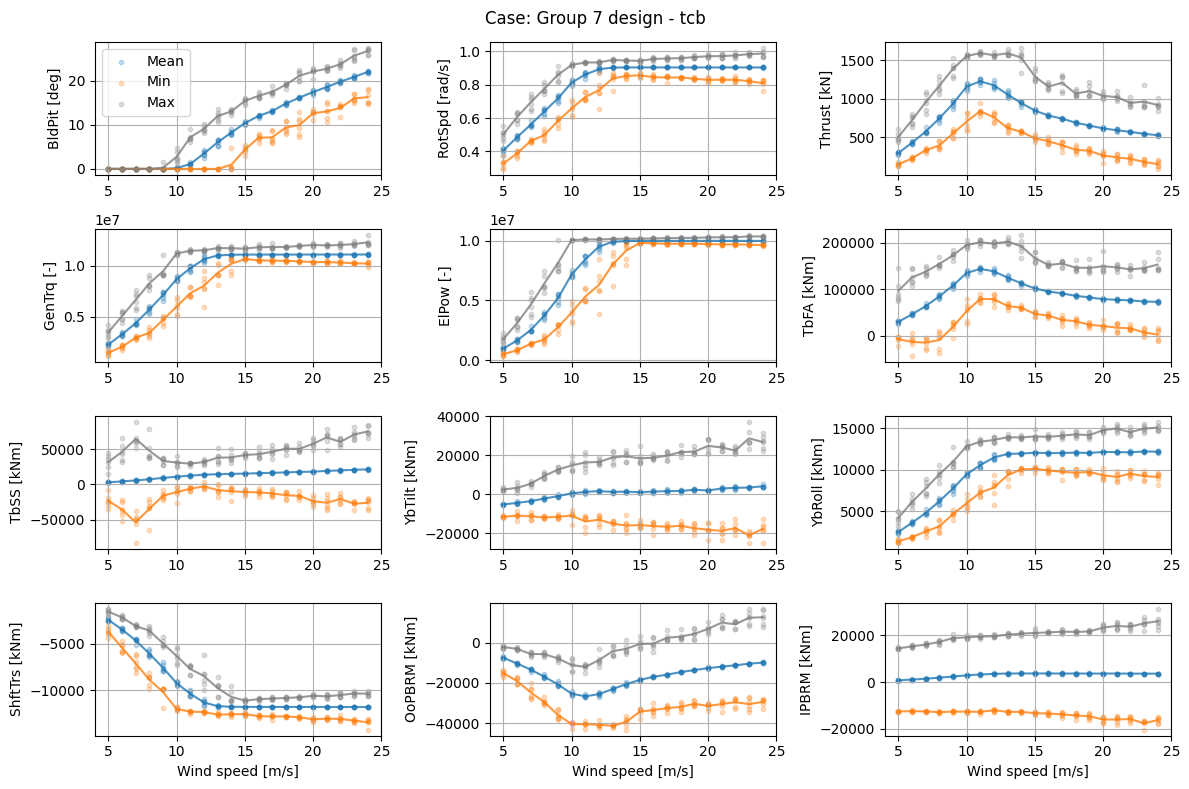

In [192]:
# analysis settings
HAWC2S_PATH = r'C:\Users\hrara\Documents\46320_LAC\LAC_Assignments_Git\hawc_files\our_design\data\group7_3B_design_flex.opt'  # path to .pwr or .opt file
STATS_PATH = r'C:\Users\hrara\Documents\46320_LAC\LAC_Assignments_Git\A4 Design Loads and AEP\Assignment/group7_turbB_stats_ts.csv'  # path to mean steady stats
SUBFOLDER = 'tcb'  # which subfolder to plot: tca or tcb

# turbine constants
GENEFF = 0.94  # generator/gearbox efficienty [%]
FG_TIMES_DY = 6250  # yaw-bearing pitch moment due to gravity [kNm]

m_tower = "del3" # "del4"
if 'notilt' in SUBFOLDER:
    DZ_YB = 2.75  # distance from hub center to yaw bearing [m]
    DZ_TB = 115.63 + DZ_YB  # distance from hub center to tower base [m]
else:
    DZ_YB = 2.75 + 7.1*np.sin(5*np.pi/180)  # distance from hub center to yaw bearing [m]
    DZ_TB = 115.63 + DZ_YB  # distance from hub center to tower base [m]
CHAN_DESCS = {'BldPit': 'pitch1 angle',  # dictionary used to identify which descriptions
              'RotSpd': 'rotor speed',  # in the HAWC2 statistics file correspond to which
              'Thrust': 'aero rotor thrust',  # channels we want
              'GenTrq': 'generator torque',
              'ElPow': 'pelec',
              'TbFA': 'momentmx mbdy:tower nodenr:   1',
              'TbSS': 'momentmy mbdy:tower nodenr:   1',
              'YbTilt': 'momentmx mbdy:tower nodenr:  11',
              'YbRoll': 'momentmy mbdy:tower nodenr:  11',
              'ShftTrs': 'momentmz mbdy:shaft nodenr:   4',
              'OoPBRM': 'momentmx mbdy:blade1 nodenr:   1 coo: hub1',
              'IPBRM': 'momentmy mbdy:blade1 nodenr:   1 coo: hub1',
              'FlpBRM': 'momentmx mbdy:blade1 nodenr:   1 coo: blade1',
              'EdgBRM': 'momentmy mbdy:blade1 nodenr:   1 coo: blade1',
              'OoPHub': 'momentmx mbdy:hub1 nodenr:   1 coo: hub1',
              'IPHub': 'momentmy mbdy:hub1 nodenr:   1 coo: hub1',
              }

# what channels we want to plot
chan_ids = ['BldPit', 'RotSpd', 'Thrust', 'GenTrq', 'ElPow', 'TbFA', 'TbSS',
            'YbTilt', 'YbRoll', 'ShftTrs', 'OoPBRM', 'IPBRM']

turb_ids = ['path', 'filename', 'subfolder', 'ichan', 'names', 'units', 'desc',
            'mean', 'max', 'min', 'std', '1%', '50%', '99%', 'del3', 'del4', 'del5',
            'del8', 'del10', 'del12', 'wsp']

# load the HAWC2 data from the stats file. Isolate the simulations with no tilt.
df, wsps = load_stats(STATS_PATH, statstype='turb')

# 10 MW file 
dtu10, wsps_dtu = load_stats('dtu_10mw_turb_stats.hdf5', subfolder="tca",statstype='turb', )

# load/calc. the stuff we need from the HAWC2S opt/pwr file for the operational data comparisons
opt_dict = load_oper(HAWC2S_PATH)
h2s_u, h2s_pitch, h2s_rotspd, = opt_dict['ws_ms'], opt_dict['pitch_deg'], opt_dict['rotor_speed_rpm']
h2s_paero, h2s_thrust = opt_dict['power_kw'], opt_dict['thrust_kn']
h2s_aerotrq = h2s_paero / (h2s_rotspd * np.pi / 30)

# get hawc2 thrust and aerodynamic torque for theoretical calculations
h2_thrust = df.filter_channel('Thrust', CHAN_DESCS)['mean']
h2_aero_trq = df.filter_channel('GenTrq', CHAN_DESCS)['mean'] / GENEFF * 1e-3  # aerodynamic torque [kNm]

# initialize the figure and axes
fig, axs = plt.subplots(4, 3, figsize=(12, 8), clear=True)

# Set the opacity and marker size variables
dot_opacity = 0.25  # Opacity for individual points
line_opacity = 0.8  # Opacity for the mean lines
dot_size = 10       # Size for individual points
line_size = 40      # Size for mean points
max_color = 'tab:gray'
mean_color = 'tab:blue'
min_color = 'tab:orange'

interested = ["TbFA", "TbSS", "IPBRM", "OoPBRM", "ShftTrs"]
dfs = []
dtu = []
# Loop over each channel and plot the steady state with the theory line
for iplot, chan_id in enumerate(chan_ids):

    
    # Isolate the channel data
    chan_df = df.filter_channel(chan_id, CHAN_DESCS)
    chan_df_dtu = dtu10.filter_channel(chan_id, CHAN_DESCS)

    # Extract HAWC2 wind and the stats ('mean', 'min', 'max') for the channel
    h2_wind = np.array(chan_df['wsp'])
    h2_wind_dtu = np.array(chan_df_dtu['wsp'])

    HAWC2val_mean = np.array(chan_df['mean'])
    HAWC2val_min = np.array(chan_df['min'])
    HAWC2val_max = np.array(chan_df['max'])


    if chan_id in interested:
        print(chan_id)
        dfs.append(chan_df)
        dtu.append(chan_df_dtu)

    # Sort HAWC2 values by increasing wind speed
    i_h2 = np.argsort(h2_wind)
    h2_wind_sorted = h2_wind[i_h2]
    HAWC2val_mean_sorted = HAWC2val_mean[i_h2]
    HAWC2val_min_sorted = HAWC2val_min[i_h2]
    HAWC2val_max_sorted = HAWC2val_max[i_h2]

    # Calculate the mean for each unique wind speed for 'mean', 'min', and 'max'
    unique_wind_speeds = np.unique(h2_wind_sorted)
    mean_HAWC2val_per_wind = [np.mean(HAWC2val_mean_sorted[h2_wind_sorted == wsp]) for wsp in unique_wind_speeds]
    min_HAWC2val_per_wind = [np.mean(HAWC2val_min_sorted[h2_wind_sorted == wsp]) for wsp in unique_wind_speeds]
    max_HAWC2val_per_wind = [np.mean(HAWC2val_max_sorted[h2_wind_sorted == wsp]) for wsp in unique_wind_speeds]

    # Plot the results
    ax = axs.flatten()[iplot]
    # Individual 'mean' values with lower opacity and smaller markers
    ax.scatter(h2_wind_sorted, HAWC2val_mean_sorted, color=mean_color, alpha=dot_opacity, s=dot_size, label='Mean')
    # Mean of 'mean' with higher opacity and larger markers
    ax.plot(unique_wind_speeds, mean_HAWC2val_per_wind, color=mean_color, alpha=line_opacity, markersize=line_size)#, label='Mean of means')

    # Individual 'min' values
    ax.scatter(h2_wind_sorted, HAWC2val_min_sorted, color=min_color, alpha=dot_opacity, s=dot_size, label='Min')
    # Mean of 'min'
    ax.plot(unique_wind_speeds, min_HAWC2val_per_wind, color=min_color, alpha=line_opacity, markersize=line_size)#, label='Mean of min')

    # Individual 'max' values
    ax.scatter(h2_wind_sorted, HAWC2val_max_sorted, color=max_color, alpha=dot_opacity, s=dot_size, label='Max')
    # Mean of 'max'
    ax.plot(unique_wind_speeds, max_HAWC2val_per_wind, color=max_color, alpha=line_opacity, markersize=line_size)#, label='Mean of max')

    # Formatting the plot
    ax.grid('on')
    ax.set(xlabel='Wind speed [m/s]' if iplot > 8 else None,
           ylabel=f'{chan_id} [{chan_df.units.iloc[0]}]', xlim=[4, 25])

# Add legends and format the figure
axs[0, 0].legend()
#axs[1, 2].legend()
fig.suptitle(f'Case: Group 7 design - {SUBFOLDER}')
fig.tight_layout()

In [148]:
len(dtu)

4

In [193]:
np.unique(h2_wind)

mean_values = [dfs[0]["del3"][i:i + 6].mean() for i in range(0, len(dfs[0]["del3"]) - 5, 6)]


# Get the sorting indices for h2_wind_dtu in increasing order
sorted_indices = np.argsort(h2_wind_dtu)

# Sort both arrays using the same indices
h2_wind_dtu_sorted = h2_wind_dtu[sorted_indices]
dtu_del3_sorted = dtu[0]["del3"].to_numpy()[sorted_indices]  # Convert to numpy array for indexing

# Convert dtu_del3_sorted back to a pandas Series if needed
dtu_del3_sorted = pd.Series(dtu_del3_sorted)
m_tbfa_dtu = dtu_del3_sorted.rolling(window=6).mean().iloc[5::6].reset_index(drop=True)


import numpy as np
import pandas as pd

def sort_and_rolling_mean(h2_wind_dtu, dtu_del3, window=6):

    # Get sorting indices for h2_wind_dtu in increasing order
    sorted_indices = np.argsort(h2_wind_dtu)

    # Sort both arrays using the same indices
    h2_wind_dtu_sorted = h2_wind_dtu[sorted_indices]
    dtu_del3_sorted = dtu_del3.to_numpy()[sorted_indices]  # Convert to numpy array for indexing

    # Convert sorted dtu_del3 back to pandas Series for rolling operation
    dtu_del3_sorted = pd.Series(dtu_del3_sorted)

    # Calculate rolling mean and select every `window` step
    m_tbfa_dtu = dtu_del3_sorted.rolling(window=window).mean().iloc[window-1::window].reset_index(drop=True)
    
    return h2_wind_dtu_sorted, m_tbfa_dtu

h2_wind_dtu_sorted, m_tbfa_dtu = sort_and_rolling_mean(h2_wind_dtu, dtu[0]["del3"])
h2_wind_dtu_sorted, m_tbss_dtu = sort_and_rolling_mean(h2_wind_dtu, dtu[1]["del3"])
h2_wind_dtu_sorted, m_oop_dtu = sort_and_rolling_mean(h2_wind_dtu, dtu[2]["del12"])
h2_wind_dtu_sorted, m_ip_dtu = sort_and_rolling_mean(h2_wind_dtu, dtu[3]["del12"])
h2_wind_dtu_sorted, m_shat_torsion_dtu = sort_and_rolling_mean(h2_wind_dtu, dtu[4]["del3"])

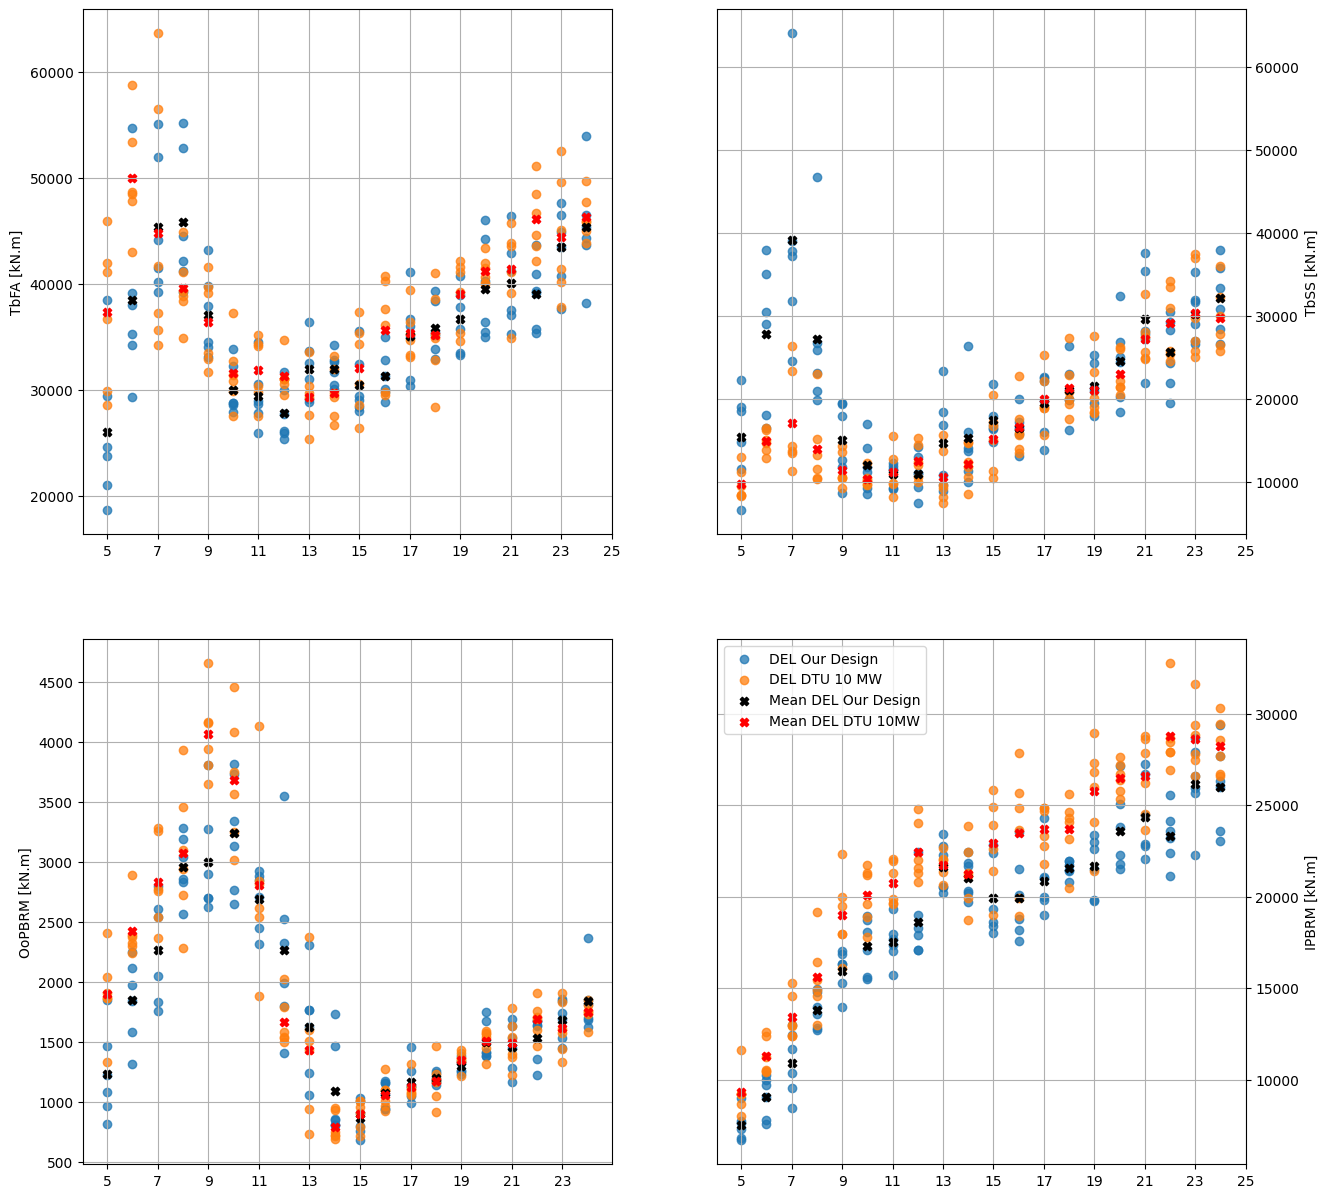

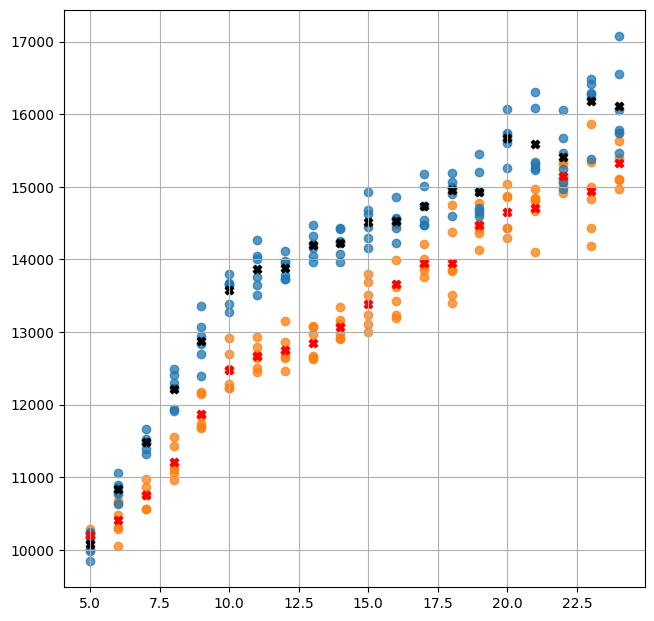

In [199]:
# Our Design

fig, axs = plt.subplots(2, 2, figsize=(15, 15))

# Plotting and setting y-axis labels
m_tbfa = [dfs[0]["del3"][i:i + 6].mean() for i in range(0, len(dfs[0]["del3"]) - 5, 6)]
axs[0, 0].scatter(h2_wind, dfs[0]["del3"], label="Our Design", c='tab:blue',alpha=0.75)
axs[0, 0].scatter(h2_wind_dtu, dtu[0]["del3"], label="DTU 10 MW", c='tab:orange', alpha=0.75)
axs[0, 0].scatter(np.unique(h2_wind), m_tbfa, label="Our Design", marker="X", c='k')
axs[0, 0].scatter(np.unique(h2_wind_dtu), m_tbfa_dtu, marker="X", c='r')
axs[0, 0].set_ylabel("TbFA [kN.m]")
axs[0, 0].set_xticks(range(5, 26,2))


m_tbss = [dfs[1]["del3"][i:i + 6].mean() for i in range(0, len(dfs[1]["del3"]) - 5, 6)]
axs[0, 1].scatter(h2_wind, dfs[1]["del3"],c='tab:blue',alpha=0.75)
axs[0, 1].scatter(h2_wind_dtu, dtu[1]["del3"], label="DTU 10 MW", c='tab:orange',alpha=0.75)
axs[0, 1].yaxis.tick_right()
axs[0, 1].yaxis.set_label_position("right")
axs[0, 1].scatter(np.unique(h2_wind), m_tbss, label="Our Design", marker="X", c='k')
axs[0, 1].scatter(np.unique(h2_wind_dtu), m_tbss_dtu, marker="X", c='r')
axs[0, 1].set_ylabel("TbSS [kN.m]")
axs[0, 1].set_xticks(range(5, 26,2))

m_oop = [dfs[2]["del12"][i:i + 6].mean() for i in range(0, len(dfs[2]["del12"]) - 5, 6)]
axs[1, 0].scatter(h2_wind, dfs[2]["del12"],c='tab:blue',alpha=0.75)
axs[1, 0].scatter(h2_wind_dtu, dtu[2]["del12"], label="DTU 10 MW", c='tab:orange',alpha=0.75)
axs[1, 0].set_ylabel("OoPBRM [kN.m]")
axs[1, 0].set_xticks(range(5, 26,2))
axs[1, 0].scatter(np.unique(h2_wind), m_oop, label="Our Design", marker="X", c='k')
axs[1, 0].scatter(np.unique(h2_wind_dtu), m_oop_dtu, marker="X", c='r')

m_ip = [dfs[3]["del12"][i:i + 6].mean() for i in range(0, len(dfs[3]["del12"]) - 5, 6)]
axs[1, 1].scatter(h2_wind, dfs[3]["del12"], c='tab:blue',alpha=0.75, label="DEL Our Design")
axs[1, 1].scatter(h2_wind_dtu, dtu[3]["del12"], label="DEL DTU 10 MW", c='tab:orange',alpha=0.75)
axs[1,1].scatter(np.unique(h2_wind), m_ip, label="Mean DEL Our Design", marker="X", c='k')
axs[1,1].scatter(np.unique(h2_wind_dtu), m_ip_dtu, marker="X", c='r', label="Mean DEL DTU 10MW")
axs[1, 1].yaxis.tick_right()
axs[1, 1].yaxis.set_label_position("right")
axs[1, 1].set_ylabel("IPBRM [kN.m]")
axs[1, 1].set_xticks(range(5, 26,2))
axs[1, 1].legend()

# Apply grid to each subplot
for ax in axs.flat:
    ax.grid()

plt.show()
fig, axs = plt.subplots(1, 1, figsize=(7.5, 7.5))
m_st = [dfs[4]["del3"][i:i + 6].mean() for i in range(0, len(dfs[4]["del3"]) - 5, 6)]
axs.scatter(h2_wind_dtu, dtu[4]["del3"], label="DTU 10MW", c='tab:orange', alpha=0.75)
axs.scatter(h2_wind, dfs[4]["del3"], label="Our Design", c='tab:blue', alpha=0.75)
axs.scatter(np.unique(h2_wind), m_st, label="Mean DEL Our Design", marker="X", c='k')
axs.scatter(np.unique(h2_wind_dtu), m_shat_torsion_dtu, label="Mean DEL DTU 10MW", marker="X", c='r')
axs.grid()
plt.show()